# Non-Boolean Quantum Amplitude Amplification

In what follows, I will be implementing the Non-Boolean Quamtum Amplitude Amplification Algorithm as seen in [`Prasanth Shyamsundar 2021`](https://arxiv.org/abs/2102.04975) 

Fundamental to the ideas in this paper is Grover's Algorithm where a quantum search is used to find the unique (choice) input for which a boolean function has output 1. More advanced is the generalized Grover's algorithm where there is a possibility of having more that one choice input for which a boolean function has output 1 (You can find my work that demonstrates this [here](https://github.com/isujeremiah/Subset-Sum-Problem)).

The non-boolean quantum amplitude amplification is an improvement of the generalized Grover's search to a scenerio where we have a non-boolean function. In some sense, it reduces to the (generalized) Grover's algorithm under some conditions (see page 7 of [`Prasanth Shyamsundar 2021`](https://arxiv.org/abs/2102.04975)).

### Important Notes
1. As a matter of convention, I have reversed the ordering of the qubit and ancilla registers in the code relative to the presentation in the paper.
2. The algorithm below is implemented for the case `n=3`, but can also work for higher values of `n`.
3. This notebook is of two sections. The first covers the algorithm as seen the the paper. The second is an application of the non-boolean quantum amplitutde amplification algorithm to risk assessment of an institution's portfolio.

### Step 1: Relevant imports

In [21]:
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit import barrier

import numpy as np
import sympy as sp

### Step 2: Generate a unitary operator $A_0$

The unitary operator will be used to change the state of the qubit register from $\ket{0}$ to $\ket{\psi_0}$. See page 4 and equation 14 in [`Prasanth Shyamsundar 2021`](https://arxiv.org/abs/2102.04975).

We display the matrix of $A_0$ and the quantum circuit after it has been applied.

Matrix([
[   0.0540236939782215 + 0.246667980666793*I, -0.145866651800147 + 0.0303732104286358*I,  -0.179293931293338 + 0.128632247759675*I,    -0.194813706854692 + 0.44805213677086*I,   -0.227657207367749 + 0.263150761489288*I,    0.288891822997843 + 0.372970855128981*I,   0.391500962065874 - 0.328563116282489*I, -0.0335051888545701 - 0.143700644773708*I],
[   -0.117010285334669 - 0.121296500025188*I,   0.0791903125643924 + 0.40499954918909*I, -0.317235615970153 - 0.0175209790490675*I,  0.539188235319051 + 0.00943197743946532*I,    0.168131095888286 - 0.114513730415003*I, -0.00227202616857622 + 0.361782657055237*I,     0.1887901474779 + 0.300114485386055*I,  -0.247597218794271 - 0.224173049056972*I],
[   -0.374030860479465 + 0.119950375139015*I,  -0.376463467537073 + 0.016792607686587*I,   0.343040728256569 - 0.167141726101878*I,   0.0692029370127933 + 0.160562453041269*I,   0.0088874261531598 - 0.127221627699208*I,    0.522100690133527 - 0.182568429100483*I,   0.159826882521668 + 0.3

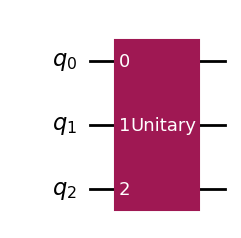

In [22]:
n = 3
N = 2 ** n

# Build a random unitary A of size (2^n x 2^n)
rng = np.random.default_rng()
Z = rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N))
Q, R = np.linalg.qr(Z)
diag = np.diag(R)
phases = np.where(np.abs(diag) > 0, diag / np.abs(diag), 1)
A_0 = Q * phases

op = Operator(A_0)

display(sp.Matrix(A_0))


qubits = QuantumRegister(n, 'q')
qc = QuantumCircuit(qubits)
qc.append(op, list(qubits))
display(qc.draw('mpl'))


### Step 3: The Diffuser Operator $S_{\Psi_0}$

The diffuser operator is called the selective phase-flip operator in the text. See `Section 2.2` of [`Prasanth Shyamsundar 2021`](https://arxiv.org/abs/2102.04975). The circuit representation is updated after each phase to show all relevant operators and gates.

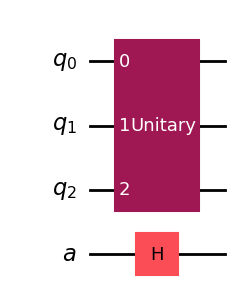

In [23]:
qubit = QuantumRegister(n, 'q')
ancilla = AncillaRegister(1, 'a')

circuit_1 = QuantumCircuit(qubit, ancilla)

circuit_1.h(ancilla)

circuit_1.append(op.adjoint(), list(qubit))

display(circuit_1.draw('mpl'))

Matrix([
[2.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

Matrix([
[1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    0,    0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    0,    0,    0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    0,    0,    0,    0,    0,    0, -1.0,    0,    0,    0,    0,    0,    0],
[  0,    0,    0,    

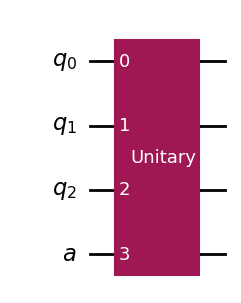

In [24]:
qubit = QuantumRegister(n, 'q')
ancilla = AncillaRegister(1, 'a')

circuit_2 = QuantumCircuit(qubit, ancilla)

# Build |psi_qubit> on n data qubits and |0> on ancilla
psi_qubit = Statevector.from_int(0, N)
psi_ancilla = Statevector.from_label('0')
psi_joint = psi_qubit.tensor(psi_ancilla)

# Build 2|psi><psi| on the full (n+1)-qubit joint system
ket = psi_joint.data
op_1 = 2 * np.outer(ket, np.conjugate(ket))

Id_data = np.eye(N)      # Identity on n data qubits
Id_ancilla = np.eye(2)         # Identity on 1 ancilla qubit
Id_joint = np.kron(Id_data, Id_ancilla)

diffuser = op_1 - Id_joint

# Apply diffuser on all data qubits plus ancilla
circuit_2.append(Operator(diffuser), list(qubit) + [ancilla[0]])

display(sp.Matrix(op_1))
display(sp.Matrix(diffuser))

display(circuit_2.draw('mpl'))


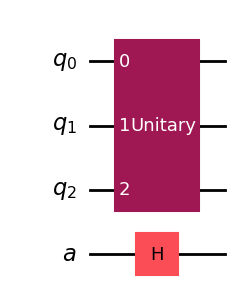

In [25]:
circuit_3 = circuit_1.inverse()
display(circuit_3.draw('mpl'))

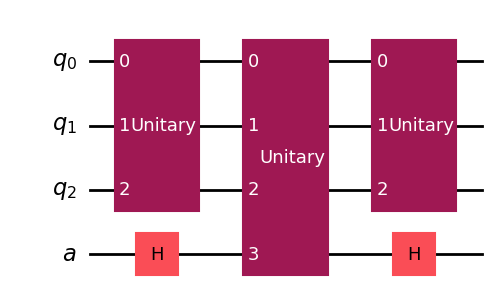

In [26]:
main_circuit = circuit_1.compose(circuit_2).compose(circuit_3)
display(main_circuit.draw('mpl'))

In [27]:
diffuser_gate = main_circuit.to_gate(label='Diffuser')

### Step 4: The Marker Oracles $-$  $U_\varphi$, and its adjoint, $U_\varphi^\dagger$

First, we construct a quantum oracle for a non-boolean function $\varphi$. See Equation 5 in page 2 of [`Prasanth Shyamsundar 2021`](https://arxiv.org/abs/2102.04975).

In [28]:
num_qubits = n
N = 2 ** num_qubits
# Define a function of range [0,1]
def f(x):
    return np.sin(x)**2

# Compute the diagonal entries of the phase oracle matrix
diagonal_entries = [np.exp(1j * np.pi * f(x)) for x in range(N)]

# Create the diagonal matrix for the phase oracle
diagonal_matrix = np.diag(diagonal_entries)


# Create the phase oracle operator
phase_oracle = Operator(diagonal_matrix)

phase_oracle_adjoint = phase_oracle.adjoint()

# Display the matrix with numerical values
sp.Matrix(phase_oracle.data) 

Matrix([
[1.0,                                       0,                                       0,                                        0,                                        0,                                       0,                                       0,                                       0],
[  0, -0.608113415652872 + 0.79385015821816*I,                                       0,                                        0,                                        0,                                       0,                                       0,                                       0],
[  0,                                       0, -0.85561664414546 + 0.517610044590772*I,                                        0,                                        0,                                       0,                                       0,                                       0],
[  0,                                       0,                                       0, 0.9980434882869

The circuits for $U_\varphi$ and $U_\varphi^\dagger$ (See figures 2 and 3 in page 6 of [`Prasanth Shyamsundar 2021`](https://arxiv.org/abs/2102.04975)):

For $U_\varphi$:

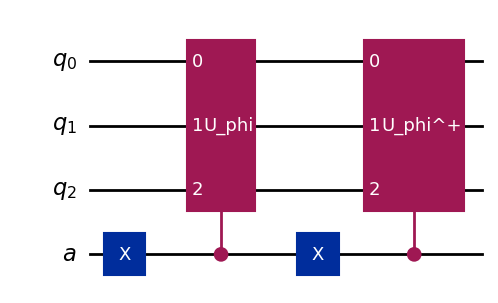

In [29]:
# Circuit for U_psi

from qiskit.circuit.library import UnitaryGate

q1 = QuantumRegister(n, 'q')
a1 = AncillaRegister(1, 'a')

U_psi_circuit = QuantumCircuit(q1, a1)

# Optional preparation of the ancilla control qubit
U_psi_circuit.x(a1[0])

# Build an n-qubit gate from the phase-oracle matrix, then control it with ancilla
phase_oracle_gate = UnitaryGate(phase_oracle.data, label='U_phi')
controlled_phase_oracle = phase_oracle_gate.control()

# Apply phase oracle controlled by ancilla: control=a1[0], targets=all q1 qubits
U_psi_circuit.append(controlled_phase_oracle, [a1[0]] + list(q1))

# Build and label the adjoint gate explicitly as U_phi^\dagger, then control it
phase_oracle_adjoint_gate = UnitaryGate(phase_oracle.adjoint().data, label='U_phi^+')
controlled_phase_oracle_adjoint = phase_oracle_adjoint_gate.control()

U_psi_circuit.x(a1[0])  # Flip ancilla back to |0> for the second controlled operation

# Apply adjoint of phase oracle controlled by ancilla: control=a1[0], targets=all q1 qubits
U_psi_circuit.append(controlled_phase_oracle_adjoint, [a1[0]] + list(q1))

display(U_psi_circuit.draw('mpl'))

In [30]:
odd_gate = U_psi_circuit.to_gate(label='U_psi')

For $U_\varphi ^ \dagger$:

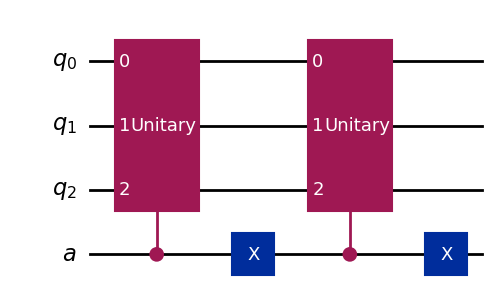

In [31]:
# Circuit for the adjoint of U_psi

U_psi_adjoint_circuit = U_psi_circuit.inverse()

display(U_psi_adjoint_circuit.draw('mpl'))

In [32]:
even_gate = U_psi_adjoint_circuit.to_gate(label='U_psi^+')

### Step 5: The odd and even iterations

The alternation between odd and even iterations is a key difference between this algorithm and the boolean one.

Odd iteration:

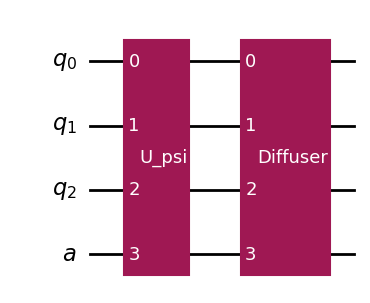

In [33]:
q1 = QuantumRegister(n, 'q')
a1 = AncillaRegister(1, 'a')
odd_iteration_circuit = QuantumCircuit(q1, a1)
odd_iteration_circuit.append(odd_gate, list(q1) + [a1[0]])  
odd_iteration_circuit.append(diffuser_gate, list(q1) + [a1[0]])

display(odd_iteration_circuit.draw('mpl'))

In [34]:
odd_gate = U_psi_adjoint_circuit.to_gate(label='Odd Iteration')

Even iteration:

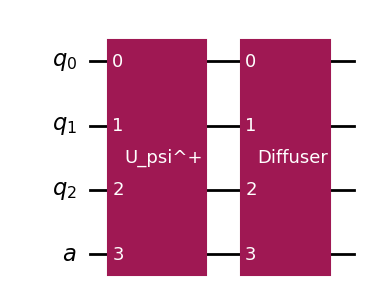

In [35]:
q1 = QuantumRegister(n, 'q')
a1 = AncillaRegister(1, 'a')
even_iteration_circuit = QuantumCircuit(q1, a1)
even_iteration_circuit.append(even_gate, list(q1) + [a1[0]])
even_iteration_circuit.append(diffuser_gate, list(q1) + [a1[0]])

display(even_iteration_circuit.draw('mpl'))

In [36]:
even_gate = U_psi_adjoint_circuit.to_gate(label='Even Iteration')

### Step 6: The Non-Boolean Amplitude Amplification Algorithm Quantum Circuit

This circuit is shown in Figure 4 of the paper.

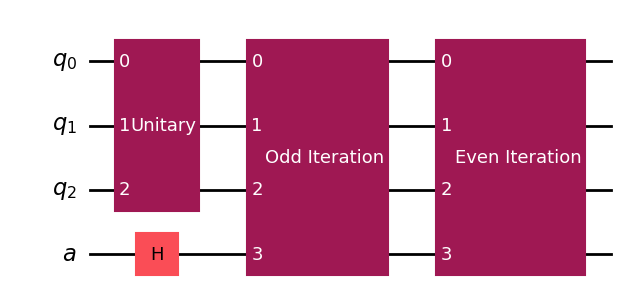

In [37]:
q1 = QuantumRegister(n, 'q')

a1 = AncillaRegister(1, 'a')

circuit = QuantumCircuit(q1, a1, name='Main Circuit')

circuit.append(op, list(q1))
circuit.h(a1[0])

odd = circuit.append(odd_gate, list(q1) + [a1[0]])

even = circuit.append(even_gate, list(q1) + [a1[0]])

circuit.draw('mpl')

### Step 7: The Non-Boolean Quantum Amplitude Amplification Algorithm

Matrix([
[  0.0382005203567473 + 0.174420601831081*I],
[  0.0382005203567473 + 0.174420601831081*I],
[ -0.082738766228717 - 0.0857695777020045*I],
[ -0.082738766228717 - 0.0857695777020045*I],
[ -0.264479757818069 + 0.0848177236666681*I],
[ -0.264479757818069 + 0.0848177236666681*I],
[-0.000310549887833997 - 0.20797298016539*I],
[-0.000310549887833997 - 0.20797298016539*I],
[  -0.338416596745102 + 0.252796221051702*I],
[  -0.338416596745102 + 0.252796221051702*I],
[ 0.0325496985531947 - 0.0427444832225095*I],
[ 0.0325496985531947 - 0.0427444832225095*I],
[  -0.178954912818611 + 0.285792548410843*I],
[  -0.178954912818611 + 0.285792548410843*I],
[-0.196160879430646 - 0.00446948777978632*I],
[-0.196160879430646 - 0.00446948777978632*I]])

Optimal angle (in radians): 1.4188288110637006


Matrix([
[  -0.111440501014558 - 0.080621370127634*I],
[ -0.106424969213552 + 0.0574550005228307*I],
[  -0.182426469856481 - 0.215828072980203*I],
[ 0.194512957363215 - 0.00820359644693699*I],
[  -0.416201900871195 - 0.304477147589561*I],
[ -0.241509624278713 + 0.0144918468924017*I],
[  -0.171959601126868 + 0.231433792783096*I],
[  0.122105565793394 - 0.0585227543448066*I],
[   0.265176616087291 - 0.158996989348254*I],
[ 0.00369525175126124 + 0.343442845771522*I],
[  -0.150303909316778 - 0.153036720470119*I],
[ 0.0714148992829612 - 0.0480065126679199*I],
[ -0.0358520250867663 + 0.172960463477987*I],
[ -0.0660123476980471 + 0.319983582612933*I],
[-0.0335565486929441 + 0.0817285137332299*I],
[-0.0437121131891058 + 0.0900596842783897*I]])

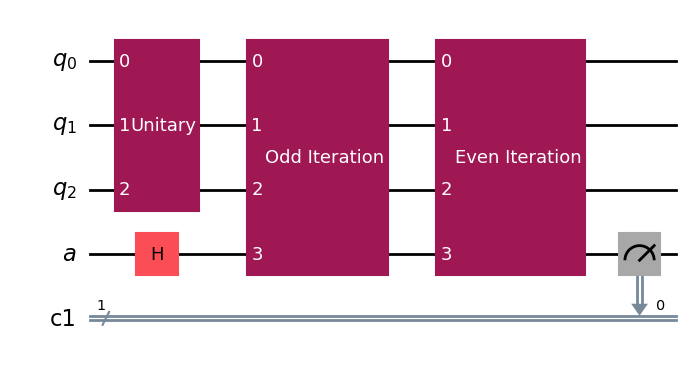

In [38]:
zero_data = Statevector.from_int(0, N).data.reshape((N, 1))
zero_anc = np.array([[1], [0]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

psi_0 = op.data @ zero_data
psi = np.kron(psi_0, H @ zero_anc)
display(sp.Matrix(psi))

def optimal_angle():
    total = 0.0
    for x, num in enumerate(psi_0[:, 0]):
        total += abs(num)**2 * np.cos(np.pi * f(x))

    return np.arccos(np.clip(total.real, -1.0, 1.0))

angle = optimal_angle()

print("Optimal angle (in radians):", angle)
K = int(np.floor(np.pi/(2*angle)))

# Use full iteration operators: oracle part composed with diffuser
even_matrix = Operator(even_iteration_circuit).data
odd_matrix = Operator(odd_iteration_circuit).data
for k in range(K):
    if k % 2 == 0:
        psi = even_matrix @ psi
    else:
        psi = odd_matrix @ psi

display(sp.Matrix(psi))

measured_circuit = circuit.copy()
c1 = ClassicalRegister(1, 'c1')
measured_circuit.add_register(c1)
measured_circuit.measure(a1[0], c1[0])

display(measured_circuit.draw('mpl'))

In [39]:
from qiskit.quantum_info import DensityMatrix, partial_trace

sv = Statevector(psi.reshape(-1))
outcome, collapsed = sv.measure([1])   # measure ancilla only
rho_q1_after = partial_trace(DensityMatrix(collapsed), [1])

print("ancilla outcome:", outcome)
display(sp.Matrix(rho_q1_after.data))

ancilla outcome: 1


Matrix([
[ 0.274934500562354 + 9.27956259522872e-18*I,   -0.116064808267493 - 0.149679460566361*I,   -0.063964284082359 + 0.273117416009945*I,    -0.033202462704797 - 0.127481213660453*I,   0.208105185629953 + 0.0155671865151013*I, -0.00918092450579945 - 0.0832124189011654*I,  -0.0396514888056239 + 0.0762613215953812*I,  -0.0394637150340105 + 0.0890393634335572*I],
[   -0.116064808267493 + 0.149679460566361*I, 0.130485554050974 + 3.77039368741475e-19*I,   -0.121687402138433 - 0.150121065112771*I,   0.0834197116548521 + 0.0357407160395661*I,   -0.0963275852814313 + 0.10672458112022*I,   0.0491781576643778 + 0.0301302222920939*I,  -0.0247790328925414 - 0.0537810609218866*I,    -0.03181490628157 - 0.0590731399303859*I],
[   -0.063964284082359 - 0.273117416009945*I,   -0.121687402138433 + 0.150121065112771*I, 0.286193811272052 - 1.68058622907719e-18*I,   -0.118914024399263 + 0.0626418850657699*I,  -0.0329519556060313 - 0.210351536019837*I,  -0.0805264872968339 + 0.0284798494309189*I,   0.0

## Application: Quantum Value at Risk (QVaR)

`We apply the non-boolean quantum amplitude amplification to solving a problem in risk management of an institution's portfolio`.

**Scenario:** A financial institution estimates portfolio losses across $2^n$ market scenarios. Each scenario $x$ has:
- Probability $|\langle x|\psi_0\rangle|^2$ (encoded in quantum state $|\psi_0\rangle = A|0^n\rangle$)
- Loss amount normalized to risk score $f(x) \in [0,1]$ (where $f(x) = 1$ means worst-case loss)

**Problem:** Compute the **Value at Risk (VaR)** — the probability that portfolio losses exceed a threshold $\tau$.

**Quantum Algorithm (QVaR):**

1. **Encode probabilities:** Prepare $|\psi_0\rangle$ encoding the distribution of market scenarios
2. **Apply risk oracle:** Tag scenarios where loss $f(x) > \tau$ by flipping an ancilla qubit
3. **Amplitude amplification:** Use Grover-like iterations (via the diffuser) to amplify probability of "high-risk" states
4. **Measure ancilla:** Read ancilla outcome; probability yields $\Pr(\text{loss} > \tau)$

**Decision Rule (Hypothesis Testing):**
- $H_0$: $\mu \ge \tau$ → Portfolio VaR is **acceptable** (risk within policy limits)
- $H_1$: $\mu < \tau$ → Portfolio VaR is **unacceptable** (intervention needed)

**Quantum Advantage:** 
- Classical: $O(2^n)$ samples to estimate tail probability
- Quantum: $O(\sqrt{2^n})$ oracle calls via amplitude estimation

**Concrete Example:**
If $n=10$ (1024 market paths) and $\tau = 0.05$ (5% loss threshold), the quantum routine estimates $\Pr(\text{loss} > 0.05)$ in ~32 oracle evaluations instead of 1024 classical samples.

**Output:** Ancilla measurement probability $p$ directly gives $\Pr(\text{loss} > \tau) \approx p$.

In [40]:
# Quantum Value at Risk (QVaR) Application for n=4
# Set threshold tau = 0.5 (50% loss threshold)

# Reconfigure for n=2
n = 2
N = 2 ** n  # N = 4 market scenarios

# Build a random unitary A of size (4 x 4)
rng = np.random.default_rng(seed=42)
Z = rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N))
Q, R = np.linalg.qr(Z)
diag = np.diag(R)
phases = np.where(np.abs(diag) > 0, diag / np.abs(diag), 1)
A = Q * phases

op = Operator(A)

# Display the random unitary matrix A
display(sp.Matrix(A))  

# Prepare |psi_0> = A|0^4>
psi_0 = op.data @ Statevector.from_int(0, N).data.reshape((N, 1))

print(f"\n|psi_0> probabilities (first 8 states):")
for x in range(N):
    prob = abs(psi_0[x, 0])**2
    print(f"  State {x}: {prob:.4f}")

# Define risk function f(x) for portfolio loss scenarios
def f(x):
    # Risk score: maps scenario to loss magnitude in [0,1]
    return np.sin(x)**2

# Build phase oracle with risk scores
diagonal_entries = [np.exp(1j * np.pi * f(x)) for x in range(N)]
diagonal_matrix = np.diag(diagonal_entries)
phase_oracle = Operator(diagonal_matrix)

print(f"\nRisk scores f(x) for all scenarios:")
for x in range(N):
    print(f"  Scenario {x}: f(x) = {f(x):.4f}")

# Compute optimal angle for weighted-mean decision
total = 0.0
for x in range(N):
    total += abs(psi_0[x, 0])**2 * np.cos(np.pi * f(x))

mu = total.real
theta = np.arccos(np.clip(mu, -1.0, 1.0))

print(f"\nWeighted-mean calculation:")
print(f"  μ = {mu:.4f}")
print(f"  θ = arccos(μ) = {theta:.4f} radians")

# Set VaR threshold
tau = 0.5
print(f"\nVaR Threshold: τ = {tau}")
print(f"  Decision: μ ≥ τ? {mu >= tau}")
if mu >= tau:
    print(f"  Conclusion: Portfolio VaR is ACCEPTABLE (μ={mu:.4f} ≥ {tau})")
else:
    print(f"  Conclusion: Portfolio VaR is UNACCEPTABLE (μ={mu:.4f} < {tau})")

# Compute number of iterations
K = int(np.floor(np.pi / (2 * theta)))
print(f"\nNumber of iterations: K = {K}")

# Build QVaR circuit
q1 = QuantumRegister(n, 'q1')
a1 = AncillaRegister(1, 'a1')

# Construct oracle and diffuser
from qiskit.circuit.library import UnitaryGate

U_psi_circuit = QuantumCircuit(q1, a1)
U_psi_circuit.x(a1[0])

phase_oracle_gate = UnitaryGate(phase_oracle.data, label='U_phi')
controlled_phase_oracle = phase_oracle_gate.control()
U_psi_circuit.append(controlled_phase_oracle, [a1[0]] + list(q1))

phase_oracle_adjoint_gate = UnitaryGate(phase_oracle.adjoint().data, label='U_phi^+')
controlled_phase_oracle_adjoint = phase_oracle_adjoint_gate.control()
U_psi_circuit.x(a1[0])
U_psi_circuit.append(controlled_phase_oracle_adjoint, [a1[0]] + list(q1))

oracle_gate = U_psi_circuit.to_gate(label='Oracle')

# Build diffuser 
psi_joint = Statevector.from_int(0, N).tensor(Statevector.from_label('0'))
ket = psi_joint.data
op_1 = 2 * np.outer(ket, np.conjugate(ket))
Id_joint = np.kron(np.eye(N), np.eye(2))
diffuser = op_1 - Id_joint
diffuser_gate = Operator(diffuser).to_instruction()

# Main QVaR circuit
circuit = QuantumCircuit(q1, a1, name='QVaR Circuit')
circuit.append(op, list(q1))
circuit.h(a1[0])
circuit.append(oracle_gate, list(q1) + [a1[0]])
circuit.append(diffuser_gate, list(q1) + [a1[0]])

print(f"\nQVaR Circuit built with {n} data qubits + 1 ancilla qubit")

## Build iteration operator (single pass through oracle + diffuser)
circuit_matrix = Operator(circuit).data

# Simulate state evolution with K iterations
zero_data = Statevector.from_int(0, N).data.reshape((N, 1))
zero_anc = np.array([[1], [0]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

psi_init = np.kron(psi_0, H @ zero_anc)
psi = psi_init

# Apply K iterations of the circuit
for k in range(K):
    psi = circuit_matrix @ psi

# Measure ancilla to get VaR probability
# States with ancilla |0>: indices 0 to N-1
# States with ancilla |1>: indices N to 2N-1
ancilla_prob_0 = np.sum([abs(psi[i, 0])**2 for i in range(N)])
ancilla_prob_1 = np.sum([abs(psi[i, 0])**2 for i in range(N, 2*N)])

print(f"\nQVaR Result:")
print(f"  Ancilla measurement P(0) = {ancilla_prob_0:.4f}")
print(f"  Ancilla measurement P(1) = {ancilla_prob_1:.4f}")
print(f"  Estimated Pr(loss > τ) ≈ {ancilla_prob_1:.4f}")
print(f"  Risk assessment: Portfolio has ~{ancilla_prob_1*100:.1f}% probability of exceeding {tau*100:.0f}% loss threshold")

Matrix([
[   0.144808189510091 + 0.175238399719655*I, -0.518928155119041 - 0.524242589647419*I, -0.149558582446561 + 0.312754999049418*I,   0.169134814312318 - 0.505386311758373*I],
[ -0.927174392610764 - 0.0878506193191362*I,  -0.112603306296399 - 0.18185849630302*I,  0.122558718637095 + 0.096402861143296*I, -0.244985090365653 - 0.0504584131100186*I],
[-0.00798427578076892 - 0.203550705113824*I, -0.38932055301496 - 0.0518092515315187*I,  0.260517056612745 + 0.328640248088538*I,   0.445173075414536 + 0.655893324954517*I],
[  0.0313792248653532 + 0.196139521569163*I, 0.498047497190279 + 0.0884604926303726*I,  0.340788653169529 + 0.750660998225316*I,  0.0146480652425889 - 0.157558426973866*I]])


|psi_0> probabilities (first 8 states):
  State 0: 0.0517
  State 1: 0.8674
  State 2: 0.0415
  State 3: 0.0395

Risk scores f(x) for all scenarios:
  Scenario 0: f(x) = 0.0000
  Scenario 1: f(x) = 0.7081
  Scenario 2: f(x) = 0.8268
  Scenario 3: f(x) = 0.0199

Weighted-mean calculation:
  μ = -0.4719
  θ = arccos(μ) = 2.0623 radians

VaR Threshold: τ = 0.5
  Decision: μ ≥ τ? False
  Conclusion: Portfolio VaR is UNACCEPTABLE (μ=-0.4719 < 0.5)

Number of iterations: K = 0

QVaR Circuit built with 2 data qubits + 1 ancilla qubit

QVaR Result:
  Ancilla measurement P(0) = 0.9190
  Ancilla measurement P(1) = 0.0810
  Estimated Pr(loss > τ) ≈ 0.0810
  Risk assessment: Portfolio has ~8.1% probability of exceeding 50% loss threshold
